In [130]:
%load_ext autoreload
%autoreload 2


from paper_utils import *


def get_arg_df(configs):
    # now add the config args to both dfs
    arg_df = []
    for wandbid, config in configs.items():
        try:
            arg_df.append([wandbid] + [config[arg.replace('.', '_')] for arg in args])
        except:
            arg_df.append([wandbid] + [config[arg] for arg in args])
        
    arg_df = pd.DataFrame(arg_df, columns=['wandbid'] + ['c.' + arg for arg in args])

    unique_cols = []
    for column in arg_df.columns[1:]:
        if column in ['name', 'c.slurmid', 'c.state']:
            continue
        if len(arg_df[column].unique()) > 1:
            unique_cols += [column]
    uniq_name = 'UNIQ-' + '-'.join(unique_cols)
    arg_df[uniq_name] = arg_df.apply(
        lambda x: '-'.join([str(x[col]) for col in unique_cols]),
        axis=1)


    return arg_df, uniq_name, unique_cols

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import wandb

api = wandb.Api()
api_runs = api.runs('goatml/semantic_uncertainty')


In [111]:
# args = ['state', 'slurmid', 'dataset', 'model_name', 'metric', 'entailment_model']

args = ['state', 'slurmid', 'dataset', 'model_name', 'metric', 'entailment_model']



configs = {}

for run in api_runs[:30]:
    # finished = run.state == 'finished'
    # lot = 'run_25_nov' in run.description
    # if lot and finished:
    configs[run.id] = run.config
    configs[run.id]['state'] = run.state
    configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]


arg_df, uniq_name, unique_cols = get_arg_df(configs)
arg_df


,wandbid,c.state,c.slurmid,c.dataset,c.model_name,c.metric,c.entailment_model,UNIQ-c.state-c.slurmid-c.dataset-c.model_name-c.metric-c.entailment_model
0,g144xlp2,running,172295,bioasq,Llama-2-70b-chat,llm_gpt-4,gpt-3.5,running-172295-bioasq-Llama-2-70b-chat-llm_gpt...
1,pfvp6gbb,running,171914,trivia_qa,falcon-40b-instruct,llm_gpt-4,gpt-3.5,running-171914-trivia_qa-falcon-40b-instruct-l...
2,4xgq8glf,running,171915,squad,falcon-40b-instruct,llm_gpt-4,gpt-3.5,running-171915-squad-falcon-40b-instruct-llm_g...
3,pp7d12fm,running,171901,squad,Llama-2-7b-chat,llm_gpt-4,gpt-3.5,running-171901-squad-Llama-2-7b-chat-llm_gpt-4...
4,64gkizzd,finished,171900,trivia_qa,Llama-2-7b-chat,llm_gpt-4,gpt-3.5,finished-171900-trivia_qa-Llama-2-7b-chat-llm_...
5,hxlw166c,running,171913,bioasq,falcon-40b-instruct,llm_gpt-4,gpt-3.5,running-171913-bioasq-falcon-40b-instruct-llm_...
6,nvgkz80j,running,171899,squad,Llama-2-70b-chat,llm_gpt-4,gpt-3.5,running-171899-squad-Llama-2-70b-chat-llm_gpt-...
7,abx2s4ve,finished,171898,trivia_qa,Llama-2-70b-chat,llm_gpt-4,gpt-3.5,finished-171898-trivia_qa-Llama-2-70b-chat-llm...
8,7ycghyoe,crashed,171896,trivia_qa,falcon-40b-instruct,llm_gpt-4,gpt-3.5,crashed-171896-trivia_qa-falcon-40b-instruct-l...
9,ipaayaf2,crashed,171897,squad,falcon-40b-instruct,llm_gpt-4,gpt-3.5,crashed-171897-squad-falcon-40b-instruct-llm_g...


Sweep over models and datasets.

* For large llama, have ablation over entailment model and metric.
* Some falcon runs failed due to rare error

In [137]:
runs = {
    'g144xlp2': 'bioasq-Llama-2-70b-chat',
    'grar15m5': 'bioasq-Llama-2-7b-chat',
    'nbcamoof': 'bioasq-falcon-40b-instruct',

    'abx2s4ve': 'trivia_qa-Llama-2-70b-chat',
    '64gkizzd': 'trivia_qa-Llama-2-7b-chat',
    'pfvp6gbb': 'trivia_qa-falcon-40b-instruct',

    'nvgkz80j': 'squad-Llama-2-70b-chat',
    'pp7d12fm': 'squad-Llama-2-7b-chat',
    'i26x8noh': 'squad-falcon-40b-instruct',

}

In [138]:
configs = {}
for run in runs:
    run = api.run(f'goatml/semantic_uncertainty/{run}')
    configs[run.id] = run.config
    configs[run.id]['state'] = run.state
    configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]

arg_df, uniq_name, unique_cols = get_arg_df(configs)
arg_df


,wandbid,c.state,c.slurmid,c.dataset,c.model_name,c.metric,c.entailment_model,UNIQ-c.dataset-c.model_name
0,g144xlp2,running,172295,bioasq,Llama-2-70b-chat,llm_gpt-4,gpt-3.5,bioasq-Llama-2-70b-chat
1,grar15m5,finished,171895,bioasq,Llama-2-7b-chat,llm_gpt-4,gpt-3.5,bioasq-Llama-2-7b-chat
2,nbcamoof,finished,171885,bioasq,falcon-40b-instruct,llm_gpt-4,gpt-3.5,bioasq-falcon-40b-instruct
3,abx2s4ve,finished,171898,trivia_qa,Llama-2-70b-chat,llm_gpt-4,gpt-3.5,trivia_qa-Llama-2-70b-chat
4,64gkizzd,finished,171900,trivia_qa,Llama-2-7b-chat,llm_gpt-4,gpt-3.5,trivia_qa-Llama-2-7b-chat
5,pfvp6gbb,running,171914,trivia_qa,falcon-40b-instruct,llm_gpt-4,gpt-3.5,trivia_qa-falcon-40b-instruct
6,nvgkz80j,finished,171899,squad,Llama-2-70b-chat,llm_gpt-4,gpt-3.5,squad-Llama-2-70b-chat
7,pp7d12fm,running,171901,squad,Llama-2-7b-chat,llm_gpt-4,gpt-3.5,squad-Llama-2-7b-chat
8,i26x8noh,running,172318,squad,falcon-40b-instruct,llm_gpt-4,gpt-3.5,squad-falcon-40b-instruct


In [162]:
for value in ['c.state', 'wandbid', 'c.slurmid']:
    display(arg_df.pivot(index='c.dataset', columns='c.model_name', values=value))

c.model_name,Llama-2-70b-chat,Llama-2-7b-chat,falcon-40b-instruct
c.dataset,,,
bioasq,running,finished,finished
squad,finished,running,running
trivia_qa,finished,finished,running


c.model_name,Llama-2-70b-chat,Llama-2-7b-chat,falcon-40b-instruct
c.dataset,,,
bioasq,g144xlp2,grar15m5,nbcamoof
squad,nvgkz80j,pp7d12fm,i26x8noh
trivia_qa,abx2s4ve,64gkizzd,pfvp6gbb


c.model_name,Llama-2-70b-chat,Llama-2-7b-chat,falcon-40b-instruct
c.dataset,,,
bioasq,172295,171895,171885
squad,171899,171901,172318
trivia_qa,171898,171900,171914


In [121]:
# compare configs between models (same dataset):

for groupby in (['c.dataset', 'c.model_name']):
    print(80 * 'x')
    print(f'Groupby {groupby}')
    
    for dataset, gdf in arg_df.groupby(groupby):
        print(80 * '-')
        print(f'{groupby}: {dataset}')
    
        wandb_ids = gdf.wandbid.values
        base, other = wandb_ids[0], wandb_ids[1:]
    
        name = lambda x: ' '.join(arg_df.set_index('wandbid').loc[x][['c.dataset', 'c.model_name']])
        cfg = deepcopy(configs)
        cfg[base].pop('slurmid')
        cfg[base].pop('state')
        for o in other:
            cfg[o].pop('slurmid')
            cfg[o].pop('state')
            print(f'{base} / {name(base)} vs {o} / {name(o)}')
            print(DeepDiff(cfg[base], cfg[o]))
        

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Groupby c.dataset
--------------------------------------------------------------------------------
c.dataset: bioasq
g144xlp2 / bioasq Llama-2-70b-chat vs grar15m5 / bioasq Llama-2-7b-chat
{'dictionary_item_added': [root['is_ood_eval']], 'values_changed': {"root['model_name']": {'new_value': 'Llama-2-7b-chat', 'old_value': 'Llama-2-70b-chat'}, "root['p_true_num_fewshot']": {'new_value': 7, 'old_value': 6}}}
g144xlp2 / bioasq Llama-2-70b-chat vs nbcamoof / bioasq falcon-40b-instruct
{'dictionary_item_added': [root['is_ood_eval']], 'values_changed': {"root['model_name']": {'new_value': 'falcon-40b-instruct', 'old_value': 'Llama-2-70b-chat'}, "root['p_true_num_fewshot']": {'new_value': 2, 'old_value': 6}}}
--------------------------------------------------------------------------------
c.dataset: squad
nvgkz80j / squad Llama-2-70b-chat vs pp7d12fm / squad Llama-2-7b-chat
{'values_changed': {"root['model_name'

Runs look coherent within each other!

Last thing that's needed to check: how do they compare against my previous 'almost perfect' runs?

In [54]:
# expected differences: 15 gens, llm_metric, gpt4_entailment
# old generate answers trivia_qa
DeepDiff(api.run('goatml/semantic_uncertainty/1gxo9oef').config, configs['abx2s4ve'])

{'dictionary_item_added': [root['random_seed'], root['recompute_accuracy'], root['compute_accuracy_at_all_temps'], root['state'], root['wandbid'], root['slurmid']],
 'values_changed': {"root['metric']": {'new_value': 'llm_gpt-4',
   'old_value': 'llm'},
  "root['model_name']": {'new_value': 'Llama-2-70b-chat',
   'old_value': 'Llama-2-70b-chat-8bit'},
  "root['num_generations']": {'new_value': 10, 'old_value': 15},
  "root['entailment_model']": {'new_value': 'gpt-3.5', 'old_value': 'gpt-4'},
  "root['p_true_num_fewshot']": {'new_value': 10, 'old_value': 5}}}

In [55]:
# generate answers squad
DeepDiff(api.run('goatml/semantic_uncertainty/uvfbxm6d').config, configs['nvgkz80j'])

{'dictionary_item_added': [root['random_seed'], root['recompute_accuracy'], root['compute_accuracy_at_all_temps'], root['state'], root['wandbid'], root['slurmid']],
 'values_changed': {"root['metric']": {'new_value': 'llm_gpt-4',
   'old_value': 'llm'},
  "root['model_name']": {'new_value': 'Llama-2-70b-chat',
   'old_value': 'Llama-2-70b-chat-8bit'},
  "root['num_generations']": {'new_value': 10, 'old_value': 15},
  "root['entailment_model']": {'new_value': 'gpt-3.5', 'old_value': 'gpt-4'},
  "root['p_true_num_fewshot']": {'new_value': 5, 'old_value': 2}}}

In [56]:
# generate answers bioasq
DeepDiff(api.run('goatml/semantic_uncertainty/dqtye228').config, configs['g144xlp2'])

{'dictionary_item_added': [root['random_seed'], root['recompute_accuracy'], root['compute_accuracy_at_all_temps'], root['state'], root['wandbid'], root['slurmid']],
 'dictionary_item_removed': [root['is_ood_eval']],
 'values_changed': {"root['metric']": {'new_value': 'llm_gpt-4',
   'old_value': 'llm'},
  "root['model_name']": {'new_value': 'Llama-2-70b-chat',
   'old_value': 'Llama-2-70b-chat-8bit'},
  "root['num_generations']": {'new_value': 10, 'old_value': 15},
  "root['entailment_model']": {'new_value': 'gpt-3.5', 'old_value': 'gpt-4'},
  "root['p_true_num_fewshot']": {'new_value': 6, 'old_value': 2}}}

In [140]:
runs = {k: runs[k] for k in runs if arg_df.set_index('wandbid').loc[k]['c.state'] == 'finished'}
runs

{'grar15m5': 'bioasq-Llama-2-7b-chat',
 'nbcamoof': 'bioasq-falcon-40b-instruct',
 'abx2s4ve': 'trivia_qa-Llama-2-70b-chat',
 '64gkizzd': 'trivia_qa-Llama-2-7b-chat',
 'nvgkz80j': 'squad-Llama-2-70b-chat'}

In [123]:
configs = {k: configs[k] for k in runs}

In [124]:
all_results = {}
for wandb_id in runs:
    all_results[wandb_id], _ = restore_file(wandb_id)

model,bioasq,squad,trivia_qa
dataset,,,
Llama-2-70b-chat,NaN,0.4225,0.8725
Llama-2-7b-chat,0.5425,NaN,0.7400
falcon-40b-instruct,0.6025,NaN,NaN


Text(0, 0.5, 'accuracy')

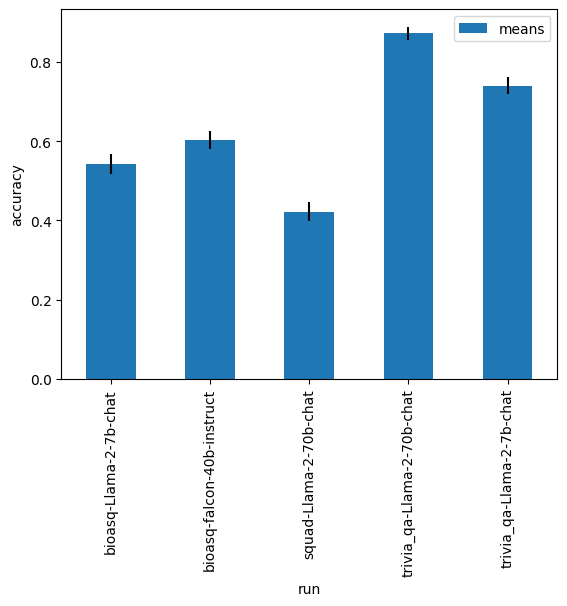

In [132]:
def get_perf_df(runs, all_results=all_results):
    perfdf = {}
    for wandb_id, run_name in runs.items():
        results = all_results[wandb_id]    
        perfdf[wandb_id] = get_perfs(results)
    
    runids = list(perfdf.keys())
    tmp = pd.DataFrame(perfdf[runids[0]])
    tmp['wandbid'] = runids[0]
    tmp['run'] = runs[runids[0]]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(perfdf[runid])
        tmp2['wandbid'] = runid
        tmp2['run'] = runs[runid]
        
        tmp = pd.concat([tmp, tmp2])
    
    perfdf = tmp.reset_index()
    
    tmp = perfdf.set_index('method').loc['accuracy']
    tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:1]))
    tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[1:]))
    display(tmp.pivot(columns='model', index='dataset', values='means'))

    pdfs = {}
    for wandb_id in runs:
        results = all_results[wandb_id]
        pdfs[wandb_id] = get_uncertainty_df(results)
    
    runids = list(pdfs.keys())

    tmp = pd.DataFrame(pdfs[runids[0]])
    tmp['run'] = runs[runids[0]]
    tmp['wandbid'] = runids[0]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(pdfs[runid])
        tmp2['run'] = runs[runid]
        tmp2['wandbid'] = runid
    
        tmp = pd.concat([tmp, tmp2])
    
    all_runs = tmp.reset_index()

    return perfdf, pdfs, all_runs

perfdf, pdfs, all_runs = get_perf_df(runs)

perfdf = perfdf.merge(arg_df, on='wandbid')
all_runs = all_runs.merge(arg_df, on='wandbid')

plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run').sort_index())
plt.gca().set_ylabel('accuracy')

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


Text(0, 0.5, 'accuracy')

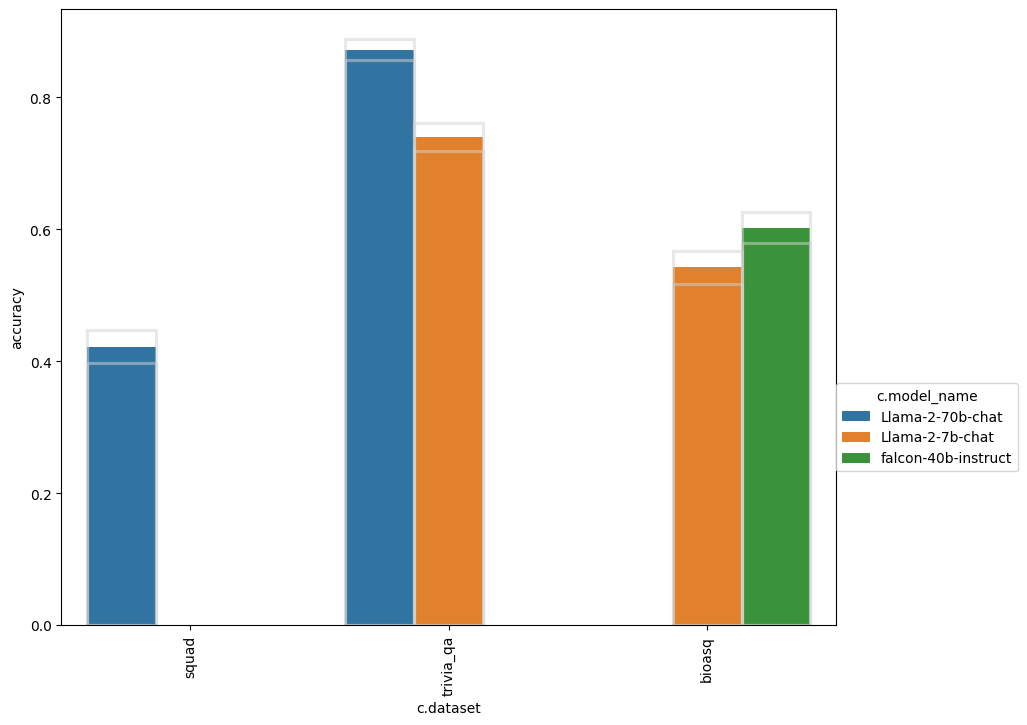

In [128]:
# just select the base entailment_model and metric, and ignore 'max_from' accuracies
acc = 'accuracy'
plot_grouped(perfdf.set_index('method').loc['accuracy'], metric='means', x='c.dataset', hue='c.model_name')
plt.gca().set_ylabel(acc)


/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


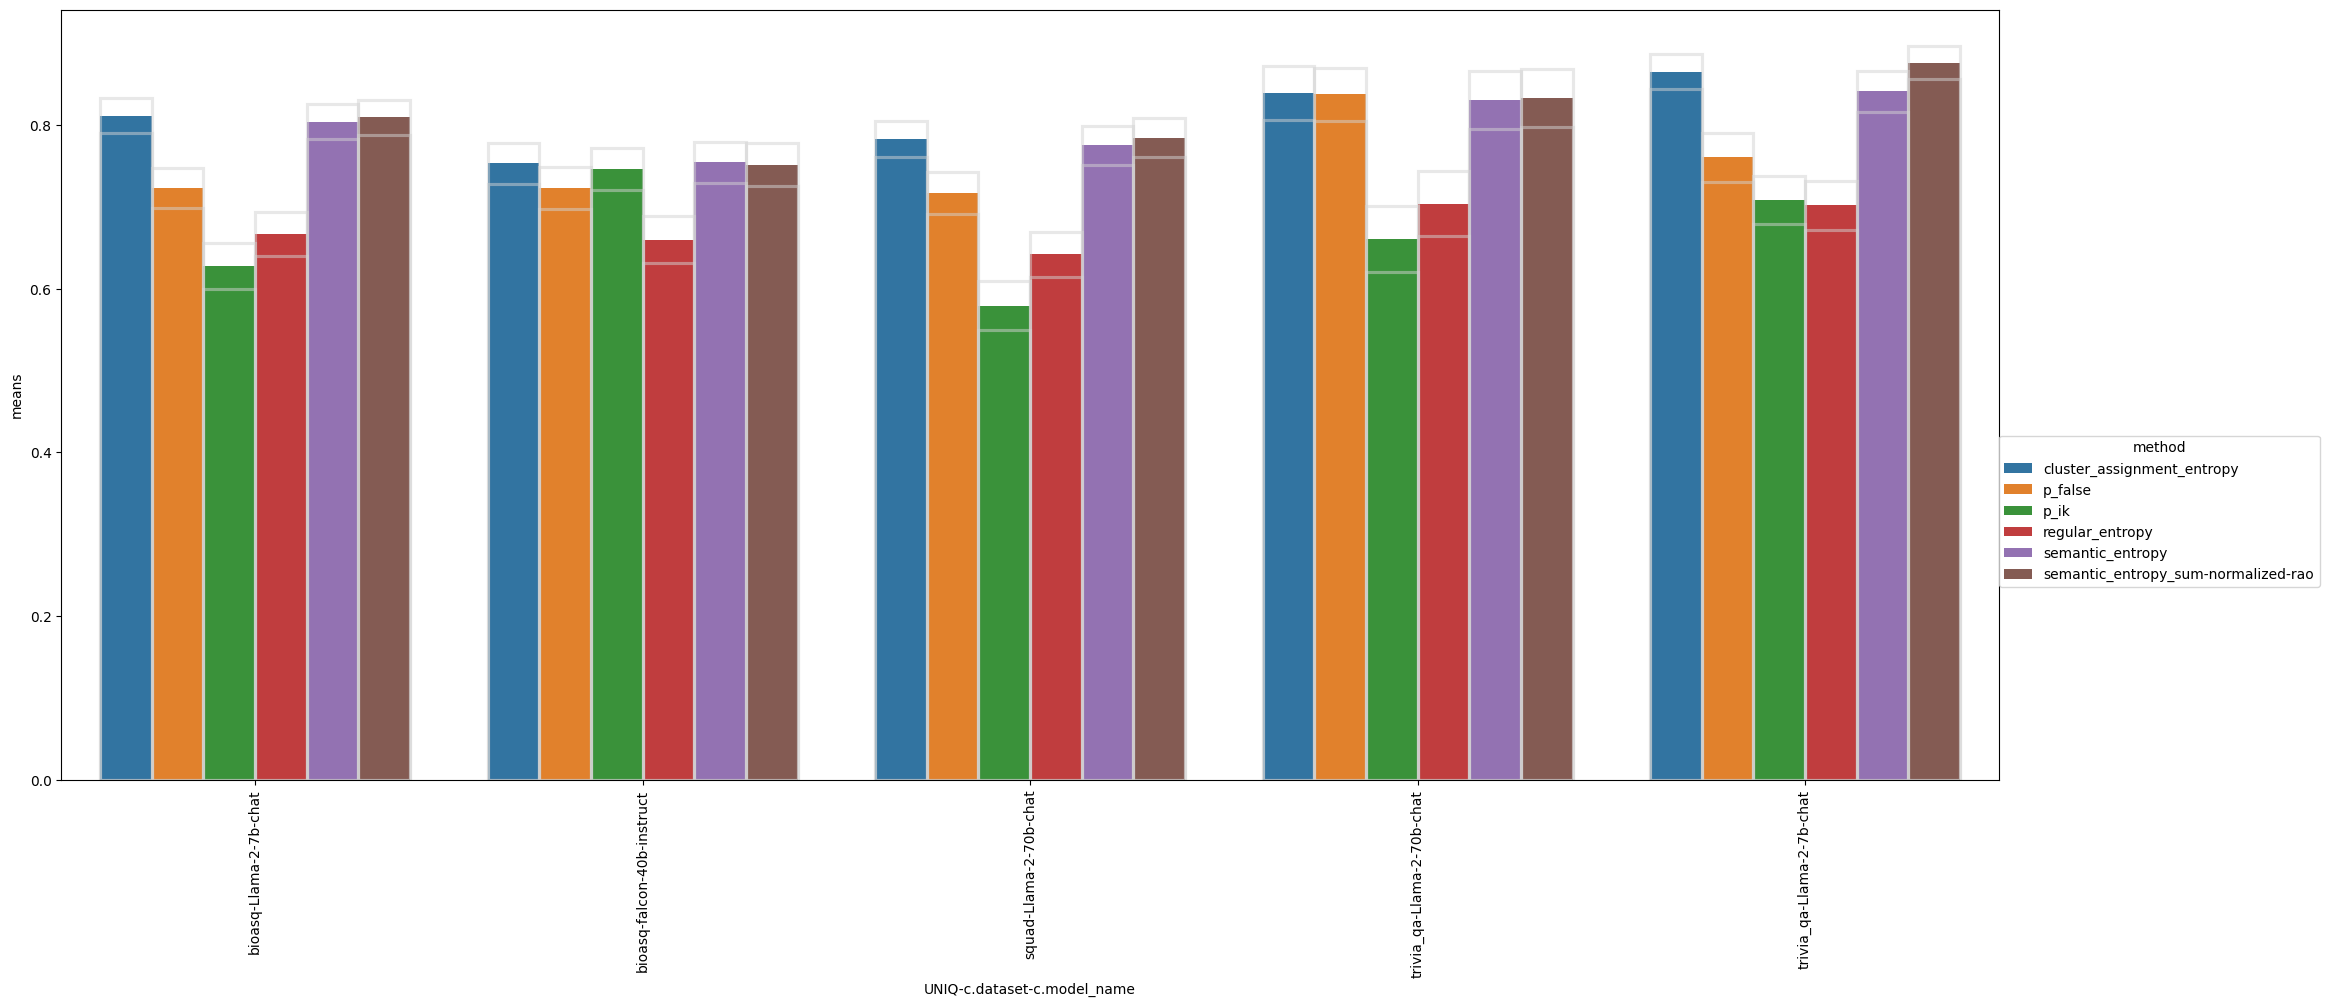

In [133]:

main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']

plot_grouped(
    all_runs.set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
    metric='means', x=uniq_name, hue='method',
    figsize=(25, 10)
)

plot the same, but per dataset

(actually, semantic entropy (and variants), are not that bad overall, especially once you start taking smaller models into account (where e.g. p_false oftens sucks))

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


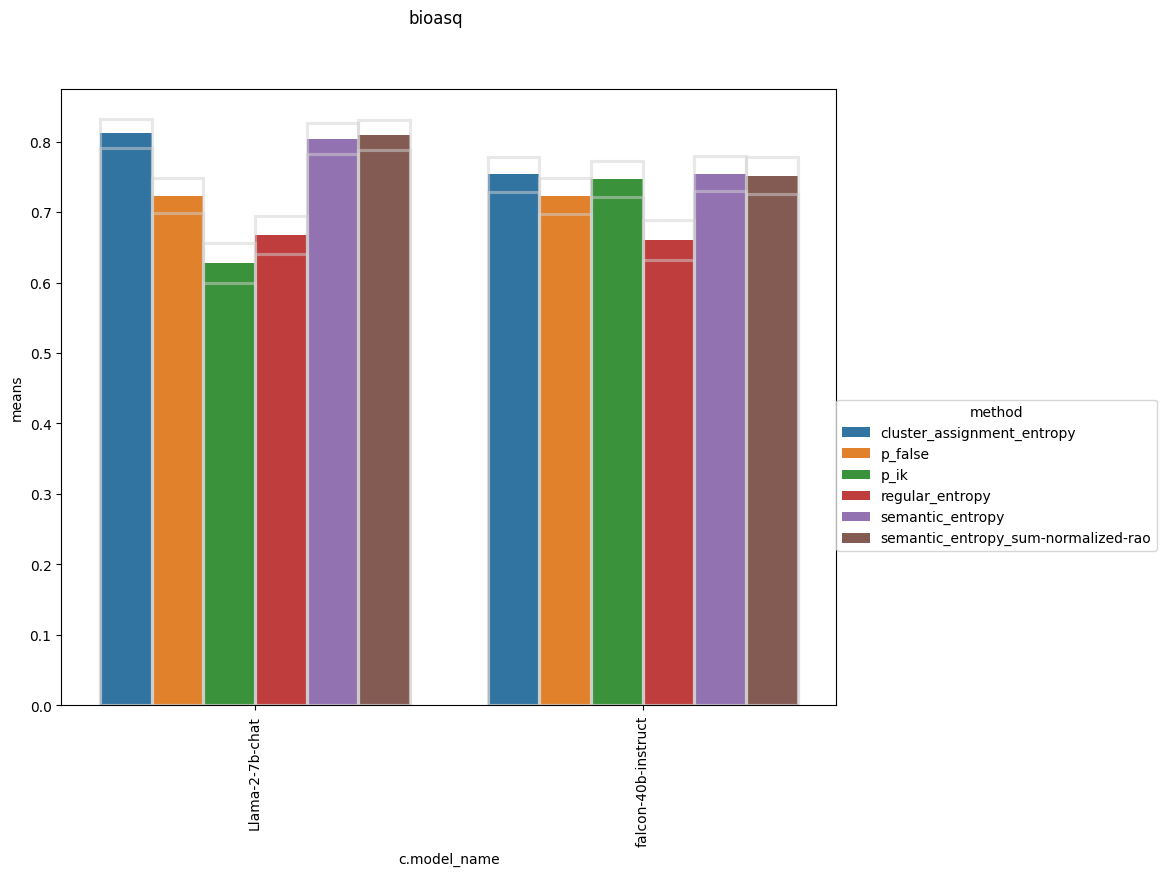

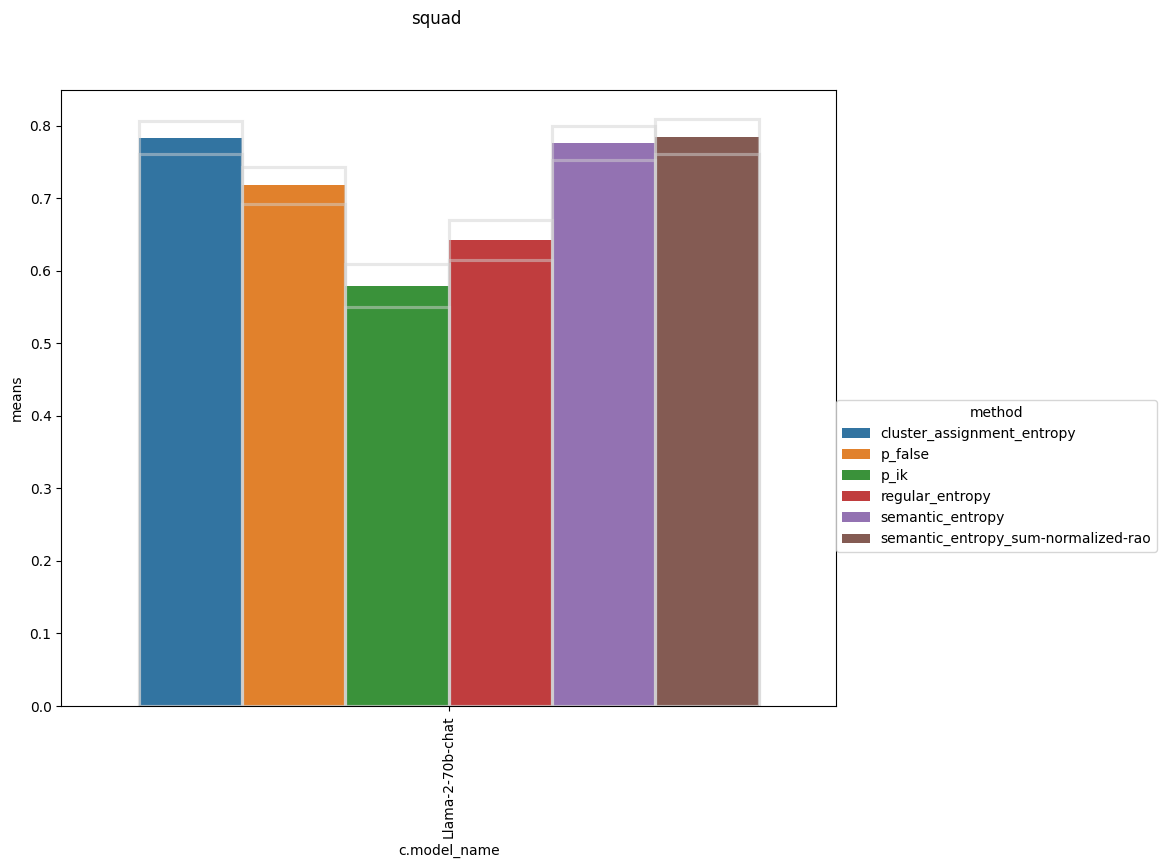

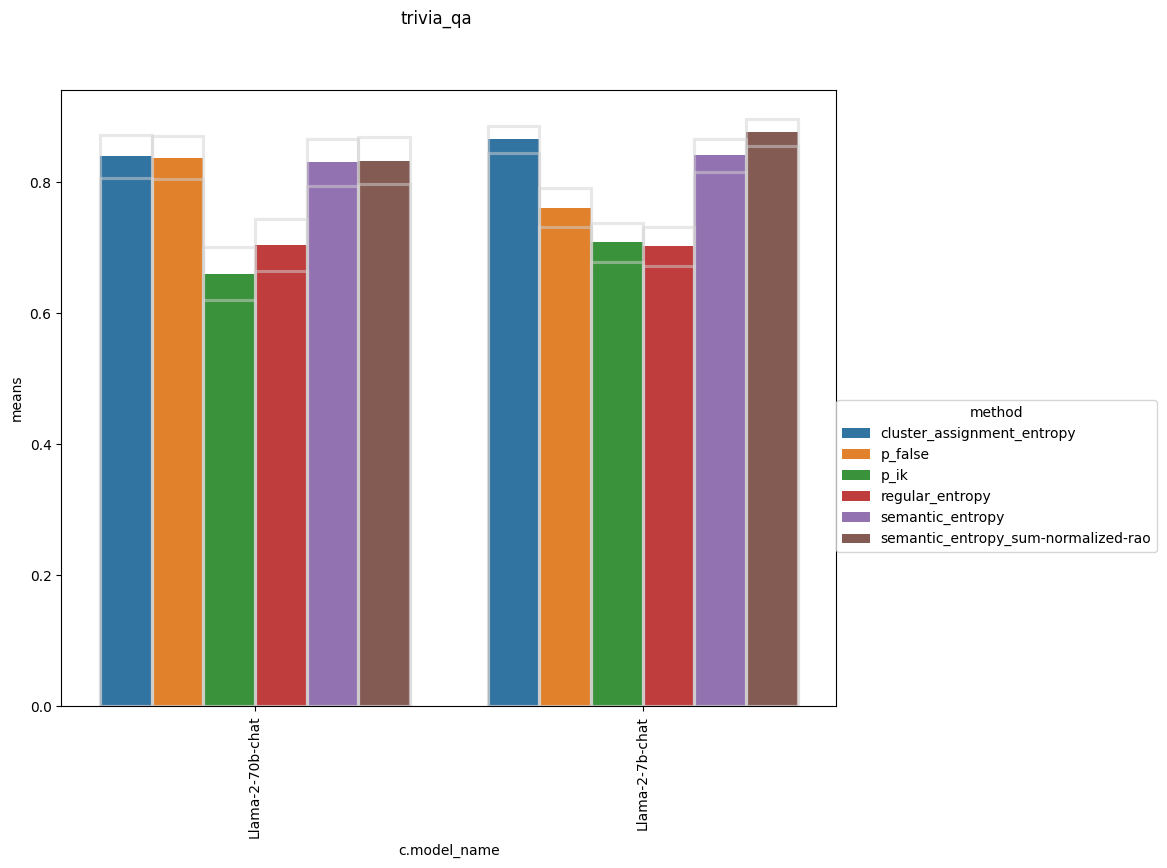

In [135]:
for dataset, gdf in all_runs.groupby('c.dataset'):

    plot_grouped(
        gdf.set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
        metric='means', x='c.model_name', hue='method',
    )
    plt.gcf().suptitle(dataset)

In [136]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)

tmp = all_runs.set_index('metric').loc['AUROC']

# select main runs (they have deberta entailment and squad metric)
tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]
tmp.groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized-rao,0.811188,0.785852,0.836524
cluster_assignment_entropy,0.810866,0.786356,0.835376
semantic_entropy,0.801412,0.775130,0.827693
semantic_entropy_sum-normalized,0.801003,0.775352,0.826655
semantic_entropy_sum_sum-normalized-rao,0.764697,0.737700,0.791693
semantic_entropy_sum_sum-normalized,0.760248,0.733804,0.786693
p_false,0.752694,0.725211,0.780177
p_false_fixed,0.752694,0.724646,0.780742
semantic_entropy_sum,0.722653,0.694010,0.751297


# Analyze length of generations

In [89]:
# read generations from run
all_gens = {}
for wandb_id in runs:
    all_gens[wandb_id] = restore_file(wandb_id, filenames=['validation_generations.pkl'])

In [91]:
from paper_utils import *

In [141]:
low_temp, high_temp, df = get_length_statistic(all_gens)
df = df.merge(arg_df[['wandbid', 'c.dataset', 'c.model_name']], on='wandbid')

df

,temp,wandbid,statistic,value,c.dataset,c.model_name
0,low,64gkizzd,mean,65.932500,trivia_qa,Llama-2-7b-chat
1,low,64gkizzd,sem,2.124421,trivia_qa,Llama-2-7b-chat
2,low,64gkizzd,std,42.435279,trivia_qa,Llama-2-7b-chat
3,low,64gkizzd,median,61.000000,trivia_qa,Llama-2-7b-chat
4,high,64gkizzd,mean,67.093000,trivia_qa,Llama-2-7b-chat
5,high,64gkizzd,sem,0.713263,trivia_qa,Llama-2-7b-chat
6,high,64gkizzd,std,45.105076,trivia_qa,Llama-2-7b-chat
7,high,64gkizzd,median,61.000000,trivia_qa,Llama-2-7b-chat
8,low,abx2s4ve,mean,72.365000,trivia_qa,Llama-2-70b-chat
9,low,abx2s4ve,sem,2.255123,trivia_qa,Llama-2-70b-chat


In [142]:
np.concatenate(list(low_temp.values()) + list(high_temp.values())).shape

(13200,)

In [143]:
stats(np.concatenate(list(low_temp.values()) + list(high_temp.values())))

{'mean': 99.00909090909092,
 'sem': 0.5846512409504407,
 'std': 67.16876918419013,
 'median': 83.0}

In [ ]:
# this is only correct for mean!!
# stats(df.set_index('statistic').loc['mean']['value'])

In [144]:
# more_detailed results per model and dataset
for name, gdf in df.groupby('temp'):
    print('temperature', name)
    display(gdf.pivot(index=['c.dataset', 'c.model_name'], columns='statistic', values='value')) 

temperature high


statistic                        mean  median       sem        std
c.dataset c.model_name                                            
bioasq    Llama-2-7b-chat   155.68225   154.0  1.056253  66.794942
trivia_qa Llama-2-70b-chat   74.78175    67.0  0.757484  47.901510
          Llama-2-7b-chat    67.09300    61.0  0.713263  45.105076

temperature low


statistic                       mean  median       sem        std
c.dataset c.model_name                                           
bioasq    Llama-2-7b-chat   153.4325   151.5  3.247561  64.869989
trivia_qa Llama-2-70b-chat   72.3650    64.0  2.255123  45.046052
          Llama-2-7b-chat    65.9325    61.0  2.124421  42.435279

In [145]:
# average length per dataset
for name, gdf in df.groupby('temp'):
    print('temperature', name)
    gdf = gdf.set_index('statistic').loc['mean'].reset_index()
    display(gdf.groupby('c.dataset').mean('value'))


temperature high


,value
c.dataset,
bioasq,155.682250
trivia_qa,70.937375


temperature low


,value
c.dataset,
bioasq,153.43250
trivia_qa,69.14875


In [146]:
# average length per model
for name, gdf in df.groupby('temp'):
    print(name)
    gdf = gdf.set_index('statistic').loc['mean']
    display(gdf.groupby('c.model_name').mean('value'))

high


,value
c.model_name,
Llama-2-70b-chat,74.781750
Llama-2-7b-chat,111.387625


low


,value
c.model_name,
Llama-2-70b-chat,72.3650
Llama-2-7b-chat,109.6825


# Cluster distribution 

In [148]:
uncertainties = {}
for wandb_id in runs:
    uncertainties[wandb_id] = restore_file(wandb_id, filenames=['uncertainty_measures.pkl'])

In [149]:
num_ids = {}
for wandbid, unc in uncertainties.items():
    unc = unc[0]
    num_ids[wandbid] = np.array([len(np.unique(s)) for s in np.array(unc['semantic_ids'])])

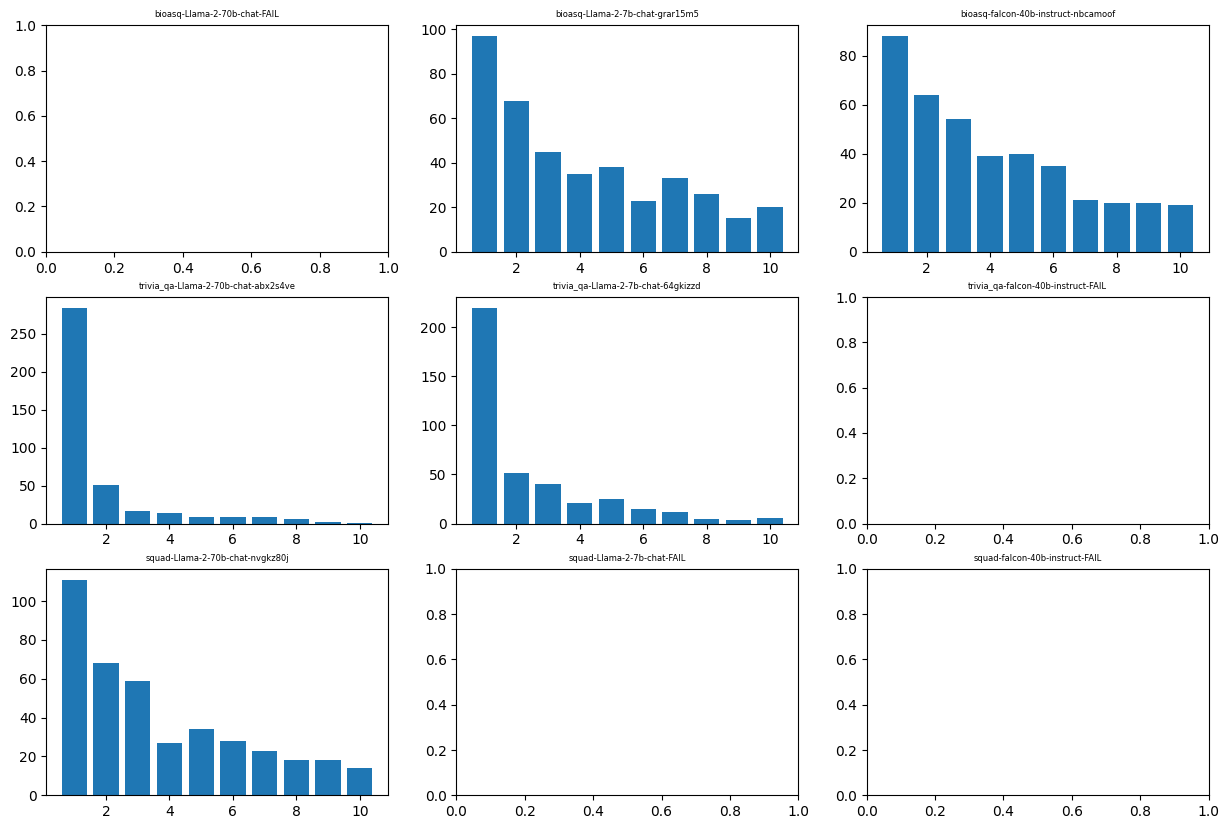

In [154]:
fig, axes_2d = plt.subplots(*arg_df[['c.dataset', 'c.model_name']].nunique().values, figsize=(15, 10))

for axes, dataset in zip(axes_2d, arg_df['c.dataset'].unique()):
    for ax, model in zip(axes, arg_df['c.model_name'].unique()):
        try:
            wid = arg_df.set_index('c.dataset').loc[dataset].set_index('c.model_name').loc[model]['wandbid']
            ax.set_title(f'{dataset}-{model}-{wid}', fontsize=6)
            uniq_counts, count_values = np.unique(num_ids[wid], return_counts=True)
            ax.bar(uniq_counts, count_values)
        except:    
            ax.set_title(f'{dataset}-{model}-FAIL', fontsize=6)
    


In [156]:
from paper_utils import *

In [157]:
cdf = get_cluster_stats(num_ids)
cdf = cdf.merge(arg_df[['wandbid', 'c.dataset', 'c.model_name']], on='wandbid')

cdf

,wandbid,statistic,value,c.dataset,c.model_name
0,grar15m5,mean,4.025000,bioasq,Llama-2-7b-chat
1,grar15m5,sem,0.139991,bioasq,Llama-2-7b-chat
2,grar15m5,std,2.796315,bioasq,Llama-2-7b-chat
3,grar15m5,median,3.000000,bioasq,Llama-2-7b-chat
4,nbcamoof,mean,4.052500,bioasq,falcon-40b-instruct
5,nbcamoof,sem,0.136504,bioasq,falcon-40b-instruct
6,nbcamoof,std,2.726673,bioasq,falcon-40b-instruct
7,nbcamoof,median,3.000000,bioasq,falcon-40b-instruct
8,abx2s4ve,mean,1.795000,trivia_qa,Llama-2-70b-chat
9,abx2s4ve,sem,0.084039,trivia_qa,Llama-2-70b-chat


In [158]:
# overall stats
stats(np.concatenate(list(num_ids.values())))

{'mean': 3.1945,
 'sem': 0.058365556144630674,
 'std': 2.6095343933353323,
 'median': 2.0}

In [159]:
display(cdf.set_index('statistic').loc['mean'].groupby('c.model_name').mean('value'))

,value
c.model_name,
Llama-2-70b-chat,2.74375
Llama-2-7b-chat,3.21625
falcon-40b-instruct,4.05250


In [161]:
display(cdf.set_index('statistic').loc['mean'].groupby('c.dataset').mean('value'))

,value
c.dataset,
bioasq,4.03875
squad,3.69250
trivia_qa,2.10125
